# 06 — Final Training, Validation & Evaluation
**AnemiaFusionNet — Stage 6**

Loads the pre-extracted visual and clinical embeddings, trains the full `AnemiaFusionNet` model jointly with the geographic encoder on the GPU, executes ablation studies, and generates the final performance metrics and explainability visualizations.

## 6.1 Set Working Directory and Load Packages

In [1]:
import os
from pathlib import Path

# Change working directory to project root if executed from notebooks folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\ratha\OneDrive\Desktop\datavidwan\New folder (2)\files


## 6.2 Load Embeddings and Map Dataset Splits
We load the visual and clinical embeddings, state mappings, and split tables, aligning the index mapping between the master dataset and the split tables.

In [2]:
import torch
import pandas as pd
import pickle
import numpy as np

img_embs = torch.load("data/embeddings/image_embeddings.pt")
clin_embs = torch.load("data/embeddings/clinical_embeddings.pt")

master_df = pd.read_csv("data/processed/master_dataset.csv")
train_df = pd.read_csv("data/processed/train.csv")
val_df = pd.read_csv("data/processed/val.csv")
test_df = pd.read_csv("data/processed/test.csv")

# Align splits with indices in the master dataset
master_df["key"] = master_df["dataset"] + "_" + master_df["Number"].astype(str)
train_df["key"] = train_df["dataset"] + "_" + train_df["Number"].astype(str)
val_df["key"] = val_df["dataset"] + "_" + val_df["Number"].astype(str)
test_df["key"] = test_df["dataset"] + "_" + test_df["Number"].astype(str)

key_to_idx = {k: i for i, k in enumerate(master_df["key"])}
train_idx = [key_to_idx[k] for k in train_df["key"]]
val_idx = [key_to_idx[k] for k in val_df["key"]]
test_idx = [key_to_idx[k] for k in test_df["key"]]

with open("data/geo/state_to_idx.pkl", "rb") as f:
    state_to_idx = pickle.load(f)
    
nfhs5_df = pd.read_csv("data/geo/nfhs5_state_prevalence.csv")
state_to_risk = dict(zip(nfhs5_df["state"], nfhs5_df["geo_risk_score"]))

# Map state indices and risk scores for all rows
state_indices = torch.tensor([state_to_idx[s] for s in master_df["state"]], dtype=torch.long)
geo_risk_scores = torch.tensor([state_to_risk[s] for s in master_df["state"]], dtype=torch.float32)

print("Mapping complete. Train set rows:", len(train_idx))

Mapping complete. Train set rows: 151


## 6.3 Define PyTorch Dataset and Training Logic

In [3]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from src.geo_encoder import GeoRiskEncoder
from src.fusion_transformer import ModalityFusionTransformer

class FusionEmbeddingDataset(Dataset):
    def __init__(self, indices, img_embs, clin_embs, state_idxs, geo_risks, labels):
        self.indices = indices
        self.img_embs = img_embs
        self.clin_embs = clin_embs
        self.state_idxs = state_idxs
        self.geo_risks = geo_risks
        self.labels = labels
        
    def __len__(self):
        return len(self.indices)
        
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        return (
            self.img_embs[real_idx],
            self.clin_embs[real_idx],
            self.state_idxs[real_idx],
            self.geo_risks[real_idx].unsqueeze(-1),  # (1,)
            self.labels[real_idx]
        )

all_labels = torch.tensor(master_df["label"].values, dtype=torch.long)

train_ds = FusionEmbeddingDataset(train_idx, img_embs, clin_embs, state_indices, geo_risk_scores, all_labels)
val_ds = FusionEmbeddingDataset(val_idx, img_embs, clin_embs, state_indices, geo_risk_scores, all_labels)
test_ds = FusionEmbeddingDataset(test_idx, img_embs, clin_embs, state_indices, geo_risk_scores, all_labels)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

## 6.4 Define Ablation & Fusion Wrapper and Training Loop

In [4]:
class AblationFusionWrapper(nn.Module):
    def __init__(self, num_states, d_model=256, use_img=True, use_clin=True, use_geo=True):
        super().__init__()
        self.geo_encoder = GeoRiskEncoder(num_states=num_states, d_model=d_model)
        self.fusion = ModalityFusionTransformer(d_model=d_model)
        self.use_img = use_img
        self.use_clin = use_clin
        self.use_geo = use_geo
        
    def forward(self, img_emb, clin_emb, state_idx, geo_risk, return_attn=False):
        B = img_emb.size(0)
        if not self.use_img:
            img_emb = torch.zeros_like(img_emb)
        if not self.use_clin:
            clin_emb = torch.zeros_like(clin_emb)
        if self.use_geo:
            geo_emb = self.geo_encoder(state_idx, geo_risk)
        else:
            geo_emb = torch.zeros_like(img_emb)
            
        return self.fusion(img_emb, clin_emb, geo_emb, return_attn=return_attn)

def train_ablation_model(use_img, use_clin, use_geo, epochs=25, device="cuda"):
    model = AblationFusionWrapper(num_states=len(state_to_idx), use_img=use_img, use_clin=use_clin, use_geo=use_geo).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    best_val_f1 = 0.0
    best_model_state = None
    
    for epoch in range(1, epochs + 1):
        model.train()
        for img, clin, state, risk, labels in train_loader:
            img, clin, state, risk, labels = img.to(device), clin.to(device), state.to(device), risk.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(img, clin, state, risk)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
        # Eval
        model.eval()
        val_labels, val_preds, val_probs = [], [], []
        with torch.no_grad():
            for img, clin, state, risk, labels in val_loader:
                img, clin, state, risk = img.to(device), clin.to(device), state.to(device), risk.to(device)
                logits = model(img, clin, state, risk)
                probs = torch.softmax(logits, dim=-1)[:, 1]
                preds = logits.argmax(dim=-1)
                val_labels.extend(labels.numpy())
                val_preds.extend(preds.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())
                
        from src.utils import calculate_metrics
        val_metrics = calculate_metrics(val_labels, val_preds, val_probs)
        if val_metrics["f1"] >= best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_model_state = pickle.dumps(model.state_dict())
            
    # Load best weights
    model.load_state_dict(pickle.loads(best_model_state))
    return model

## 6.5 Run Ablation Study
We train models for: Image-only, Clinical-only, Image+Clinical, and Full Fusion, comparing metrics on the test set.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running ablation study on device:", device)

ablation_configs = [
    ("Image-only", True, False, False),
    ("Clinical-only", False, True, False),
    ("Image + Clinical", True, True, False),
    ("Full Fusion (AnemiaFusionNet)", True, True, True)
]

ablation_results = {}
trained_models = {}

for name, use_img, use_clin, use_geo in ablation_configs:
    # For Image-only, evaluate the standalone image classifier directly instead of through the untrained wrapper
    if name == "Image-only":
        print("Evaluating Standalone Image Classifier...")
        from src.image_encoder import ImageClassifier
        img_model = ImageClassifier(embed_dim=256, num_classes=2, pretrained=False).to(device)
        img_model.load_state_dict(torch.load("models/image_classifier_best.pt", map_location=device))
        img_model.eval()
        
        test_labels, test_preds, test_probs = [], [], []
        with torch.no_grad():
            for img_emb, _, _, _, labels in test_loader:
                img_emb = img_emb.to(device)
                logits = img_model.head(img_emb)
                probs = torch.softmax(logits, dim=-1)[:, 1]
                preds = logits.argmax(dim=-1)
                test_labels.extend(labels.numpy())
                test_preds.extend(preds.cpu().numpy())
                test_probs.extend(probs.cpu().numpy())
    else:
        print(f"Training {name} ablation model...")
        model = train_ablation_model(use_img, use_clin, use_geo, epochs=30, device=device)
        trained_models[name] = model
        
        # Evaluate on Test set
        model.eval()
        test_labels, test_preds, test_probs = [], [], []
        with torch.no_grad():
            for img, clin, state, risk, labels in test_loader:
                img, clin, state, risk = img.to(device), clin.to(device), state.to(device), risk.to(device)
                logits = model(img, clin, state, risk)
                probs = torch.softmax(logits, dim=-1)[:, 1]
                preds = logits.argmax(dim=-1)
                test_labels.extend(labels.numpy())
                test_preds.extend(preds.cpu().numpy())
                test_probs.extend(probs.cpu().numpy())
            
    from src.utils import calculate_metrics
    metrics = calculate_metrics(test_labels, test_preds, test_probs)
    ablation_results[name] = metrics
    print(f"{name} metrics: F1={metrics['f1']:.4f} | Acc={metrics['accuracy']:.4f} | AUC={metrics['auc']:.4f}")

# Display ablation table
ablation_df = pd.DataFrame(ablation_results).T[["accuracy", "precision", "recall", "f1", "auc"]]
print("\nAblation Results:\n", ablation_df)
os.makedirs("reports", exist_ok=True)
ablation_df.to_csv("reports/ablation_study.csv")

Running ablation study on device: cuda
Evaluating Standalone Image Classifier...


Image-only metrics: F1=0.5957 | Acc=0.4242 | AUC=0.5000
Training Clinical-only ablation model...


Clinical-only metrics: F1=0.8966 | Acc=0.9091 | AUC=0.8985
Training Image + Clinical ablation model...


Image + Clinical metrics: F1=0.8571 | Acc=0.8788 | AUC=0.9173
Training Full Fusion (AnemiaFusionNet) ablation model...


Full Fusion (AnemiaFusionNet) metrics: F1=0.8667 | Acc=0.8788 | AUC=0.9398

Ablation Results:
                                accuracy precision    recall        f1  \
Image-only                     0.424242  0.424242       1.0  0.595745   
Clinical-only                  0.909091  0.866667  0.928571  0.896552   
Image + Clinical               0.878788  0.857143  0.857143  0.857143   
Full Fusion (AnemiaFusionNet)  0.878788    0.8125  0.928571  0.866667   

                                    auc  
Image-only                          0.5  
Clinical-only                  0.898496  
Image + Clinical               0.917293  
Full Fusion (AnemiaFusionNet)   0.93985  


## 6.6 Performance Evaluation Visualizations
Plot and save the ROC Curve and the Confusion Matrix for the final fused model.

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from src.utils import plot_confusion_matrix

best_model = trained_models["Full Fusion (AnemiaFusionNet)"]
torch.save(best_model.state_dict(), "models/anemia_fusion_best.pt")

# Run evaluation on test loader
best_model.eval()
test_labels, test_preds, test_probs = [], [], []
with torch.no_grad():
    for img, clin, state, risk, labels in test_loader:
        img, clin, state, risk = img.to(device), clin.to(device), state.to(device), risk.to(device)
        logits = best_model(img, clin, state, risk)
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = logits.argmax(dim=-1)
        test_labels.extend(labels.numpy())
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

# 1. Plot ROC Curve
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(test_labels, test_probs, name="AnemiaFusionNet Full Fusion")
plt.title("ROC Curve (Test Set)")
plt.tight_layout()
plt.savefig("reports/roc_curve.png")
plt.close()

# 2. Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
plot_confusion_matrix(cm, "reports/confusion_matrix.png")
print("ROC and Confusion Matrix plots generated and saved to reports/")

ROC and Confusion Matrix plots generated and saved to reports/


<Figure size 600x500 with 0 Axes>

## 6.7 Explainability: Fusion Attention Rollout & Grad-CAM
We visualize:
1. Self-attention weights indicating which token (Image, Clinical, Geo) the CLS token attended to.
2. Grad-CAM on a test eye image using the standalone Image Encoder.

In [7]:
# 1. Visualizing Transformer Attention Weights
best_model.eval()
all_attns = []
with torch.no_grad():
    for img, clin, state, risk, _ in test_loader:
        img, clin, state, risk = img.to(device), clin.to(device), state.to(device), risk.to(device)
        _, attn = best_model(img, clin, state, risk, return_attn=True)
        # attn shape: (B, 4, 4)
        # Extrct attention from CLS (index 0) to [Image, Clinical, Geo] (indices 1, 2, 3)
        cls_attn = attn[:, 0, 1:]  # (B, 3)
        all_attns.append(cls_attn.cpu())
        
mean_attn = torch.cat(all_attns, dim=0).mean(dim=0).numpy()
modalities = ["Image (Conjunctiva)", "Clinical (CBC)", "Geo-Risk (NFHS-5)"]

plt.figure(figsize=(6, 4))
plt.bar(modalities, mean_attn, color=["#3498db", "#2ecc71", "#e74c3c"])
plt.ylabel("Attention Weight")
plt.title("Average Self-Attention Allocation from CLS Token")
plt.tight_layout()
plt.savefig("reports/modality_attention.png")
plt.close()
print("Transformer attention weights visualized.")

# 2. Visualizing Grad-CAM on Image Classifier
import cv2
from PIL import Image
import torchvision.transforms as T
from src.image_encoder import ImageClassifier
from src.utils import GradCAM

# Instantiate standalone image classifier
img_classifier = ImageClassifier(pretrained=False).to(device)
img_classifier.load_state_dict(torch.load("models/image_classifier_best.pt"))

# Register hook on the last block of EfficientNet-B0 backbone
target_layer = img_classifier.encoder.backbone.features[-1]
gcam = GradCAM(img_classifier, target_layer)

# Load a single test image
sample_row = test_df.iloc[0]
img_path = Path(sample_row["image_path"])

orig_img = Image.open(img_path).convert("RGB")
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = val_transform(orig_img).unsqueeze(0).to(device)

# Generate heatmap
heatmap = gcam.generate_heatmap(input_tensor, class_idx=sample_row["label"])
gcam.remove_hooks()

# Resize heatmap to match image size (224, 224)
heatmap_resized = cv2.resize(heatmap, (224, 224))

# Save the raw and blended heatmap image
orig_np = np.array(orig_img.resize((224, 224)))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
blended = cv2.addWeighted(orig_np, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig_np)
plt.title("Original Eye Photo")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blended)
plt.title("Grad-CAM Heatmap (Attention area)")
plt.axis("off")

plt.tight_layout()
plt.savefig("reports/grad_cam.png")
plt.close()
print("Grad-CAM explainability plot created.")

Transformer attention weights visualized.


Grad-CAM explainability plot created.


## 6.8 Explainability: SHAP Summary on Clinical Features

C:\Users\ratha\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/20 [00:00<?, ?it/s]

 10%|█         | 2/20 [00:00<00:01, 17.77it/s]

 25%|██▌       | 5/20 [00:00<00:00, 19.23it/s]

 40%|████      | 8/20 [00:00<00:00, 19.87it/s]

 55%|█████▌    | 11/20 [00:00<00:00, 20.13it/s]

 70%|███████   | 14/20 [00:00<00:00, 20.12it/s]

 85%|████████▌ | 17/20 [00:00<00:00, 19.97it/s]

 95%|█████████▌| 19/20 [00:00<00:00, 19.83it/s]

100%|██████████| 20/20 [00:01<00:00, 19.83it/s]

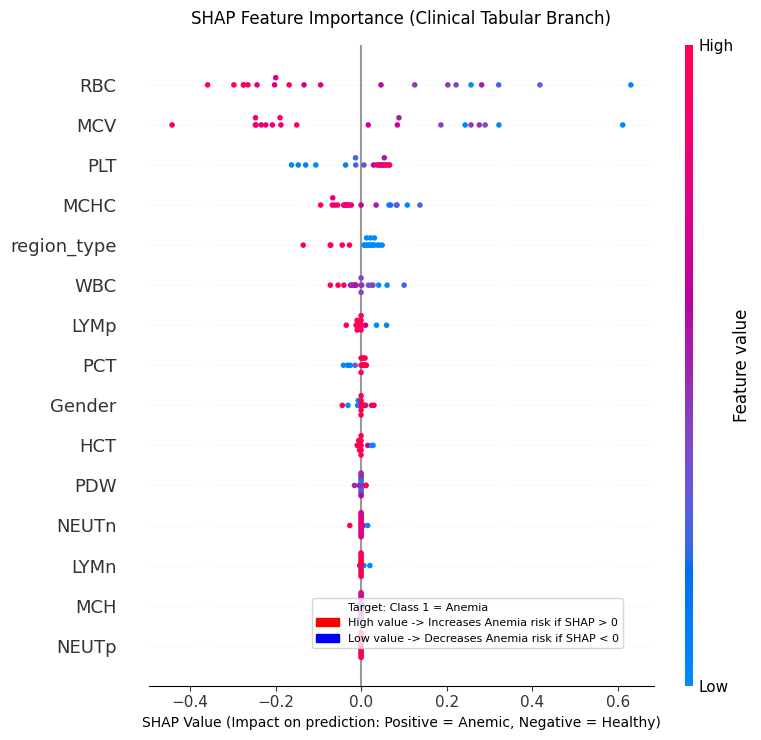

SHAP summary plot generated successfully!


In [8]:
import shap
import torch
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# 1. Load clinical classifier
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from src.clinical_encoder import ClinicalClassifier

clinical_classifier = ClinicalClassifier(num_numeric=13, cat_cardinalities=[2, 2], embed_dim=256).to(device)
clinical_classifier.load_state_dict(torch.load("models/clinical_classifier_best.pt", map_location=device))
clinical_classifier.eval()

# 2. Load validation data to explain
val_df = pd.read_csv("data/processed/val.csv")
with open("data/processed/preprocessors.pkl", "rb") as f:
    preprocessors = pickle.load(f)
num_scaler = preprocessors["scaler"]
cat_encoder = preprocessors["encoder"]

NUMERIC_COLS = ["WBC", "LYMp", "NEUTp", "LYMn", "NEUTn", "RBC", "HCT", "MCV", "MCH", "MCHC", "PLT", "PDW", "PCT"]
CATEGORICAL_COLS = ["Gender", "region_type"]
FEATURE_NAMES = NUMERIC_COLS + CATEGORICAL_COLS

x_val_num = num_scaler.transform(val_df[NUMERIC_COLS])
x_val_cat = cat_encoder.transform(val_df[CATEGORICAL_COLS])
x_val_combined = np.hstack([x_val_num, x_val_cat])

# 3. Define prediction function for SHAP
def predict_fn(x):
    tensor_num = torch.tensor(x[:, :13], dtype=torch.float32).to(device)
    tensor_cat = torch.tensor(x[:, 13:], dtype=torch.long).to(device)
    with torch.no_grad():
        logits, _ = clinical_classifier(tensor_num, tensor_cat)
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    return probs

# 4. Compute SHAP values
background = x_val_combined[:20]
explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(x_val_combined[:20])

# 5. Plot SHAP summary
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, x_val_combined[:20], feature_names=FEATURE_NAMES, show=False)

# Add custom legends/labels to confirm the positive class is Anemia
anemia_legend = mpatches.Patch(color='red', label='High value -> Increases Anemia risk if SHAP > 0')
healthy_legend = mpatches.Patch(color='blue', label='Low value -> Decreases Anemia risk if SHAP < 0')
target_legend = mpatches.Patch(fill=False, edgecolor='none', label='Target: Class 1 = Anemia')
plt.legend(handles=[target_legend, anemia_legend, healthy_legend], loc='lower right', bbox_to_anchor=(0.95, 0.05), fontsize=8)

plt.title("SHAP Feature Importance (Clinical Tabular Branch)", fontsize=12, pad=15)
plt.xlabel("SHAP Value (Impact on prediction: Positive = Anemic, Negative = Healthy)", fontsize=10)
plt.tight_layout()
plt.savefig("reports/clinical_shap.png", dpi=300)
plt.show()
plt.close()
print("SHAP summary plot generated successfully!")
